In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics


In [6]:
# Read dataset
df = pd.read_csv('Churn.csv')

# Display dataset shape and columns
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:\n", df.columns.tolist())

# Display first 5 rows
df.head()


Shape of dataset: (10000, 12)

Columns in dataset:
 ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
print(df.columns.tolist())

['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [10]:
# Select input features (X) and target output (y)
x = df[['credit_score', 'age', 'tenure', 'balance',
        'products_number', 'credit_card', 'active_member',
        'estimated_salary']]

y = df['churn']

print("\nX shape:", x.shape)
print("\nY value counts:\n", y.value_counts())



X shape: (10000, 8)

Y value counts:
 churn
0    7963
1    2037
Name: count, dtype: int64


In [12]:
# Normalize using StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("\nAfter scaling, X shape:", x_scaled.shape)



After scaling, X shape: (10000, 8)


In [14]:
# Split into train and test sets (75% train, 25% test)
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.25, random_state=0
)

print("\nTraining data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)



Training data shape: (7500, 8)
Testing data shape: (2500, 8)


In [16]:
# Create Artificial Neural Network
ann = MLPClassifier(
    hidden_layer_sizes=(100, 100, 100),
    activation='relu',
    random_state=0,
    max_iter=200
)

# Train the model
ann.fit(x_train, y_train)


C:\Users\omsaw\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(100, 100, 100), random_state=0)

In [18]:
# Predict test data
y_pred = ann.predict(x_test)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

# Accuracy
print("\nAccuracy:", metrics.accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))



Confusion Matrix:
[[1796  195]
 [ 271  238]]

Accuracy: 0.8136

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1991
           1       0.55      0.47      0.51       509

    accuracy                           0.81      2500
   macro avg       0.71      0.68      0.70      2500
weighted avg       0.80      0.81      0.81      2500



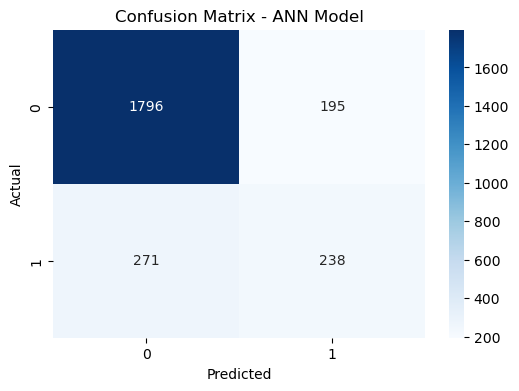

In [20]:
# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
